# Either-Or, Mutually Exclusive, and Complementary Choices

This notebook demonstrates three common logical patterns in prescriptive analytics:

- **Either-or**: at least one option must be chosen.
- **Mutually exclusive**: at most one option can be chosen.
- **Complementary**: either both options are chosen or neither is chosen.

You will see how to encode each pattern with binary variables and linear constraints, and how to verify that the model allows exactly the combinations the policy intends.

## Key Concepts

**Either-or (at least one)**
- Policy: "We must select **at least one** of A or B."
- Allowed: A only, B only, both.
- Disallowed: neither.

**Mutually exclusive (at most one)**
- Policy: "We can select **at most one** of A or B."
- Allowed: A only, B only, neither.
- Disallowed: both.

**Complementary (both or neither)**
- Policy: "A and B must be done together, or not at all."
- Allowed: both, neither.
- Disallowed: A only, B only.

**Critical insight**: Small changes in policy language ("at least one" vs "exactly one" vs "at most one") map to **different constraints**. Getting this wrong changes which combinations are allowed.

## Step 1: Install Required Packages

### Setup: Install Required Packages

To run the small optimization models in this notebook, we need the PuLP library.

**What this code does:** Installs the `pulp` package (for optimization) and supporting libraries.

**What to look for in the output:** You should see "Requirement already satisfied" if `pulp` is already installed, or installation messages if it needs to be added.

In [1]:
# Install required packages (needed in Google Colab; can be skipped locally if already installed)
%pip install pulp pandas numpy matplotlib -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

### Setup: Import Libraries

We'll use Python libraries to build tiny models and enumerate combinations.

**What this code does:** Loads `pandas` (for tables), `numpy` (for enumeration), `matplotlib` (for a simple chart), and `pulp` (for optimization).

**What to look for in the output:** No output is expected – successful imports run silently.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMaximize, LpStatus, lpSum, PULP_CBC_CMD

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Step 3: Scenario Setup – Two Vendor Options

To keep things transparent, we'll use a very small example with **two vendors**:

- `Vendor_A`
- `Vendor_B`

We'll assume each vendor has a simple benefit score. The exact numbers are not important – we care about which **combinations** are allowed under each logical rule.

We will reuse the same vendors for all three patterns:
- Either-or
- Mutually exclusive
- Complementary

In [3]:
vendors = ["Vendor_A", "Vendor_B"]
benefits = {"Vendor_A": 10, "Vendor_B": 12}

print("VENDORS:")
for v in vendors:
    print(f"  {v}: benefit {benefits[v]}")

VENDORS:
  Vendor_A: benefit 10
  Vendor_B: benefit 12


## Step 4: Either-Or Constraint (At Least One Selected)

Policy: "We must select **at least one** of Vendor A or Vendor B."

In binary terms with variables `x_A` and `x_B`:
- Either-or (≥1) is encoded as:  
  `x_A + x_B ≥ 1`

**What this code does:**
- Builds a tiny model with decision variables for each vendor.
- Adds the either-or constraint `x_A + x_B ≥ 1`.
- Uses a simple objective (maximize benefit) so the solver chooses a concrete combination.
- Enumerates **all four possible combinations** and checks which ones satisfy the constraint.

**What to look for in the output:**
- The combination chosen by the model.
- A table showing which combinations are allowed vs disallowed under the either-or rule.

In [4]:
# Either-or model: x_A + x_B >= 1

model_either_or = LpProblem("Either_Or_Vendors", LpMaximize)

x_A = LpVariable("x_A", lowBound=0, upBound=1, cat="Binary")
x_B = LpVariable("x_B", lowBound=0, upBound=1, cat="Binary")

# Objective: maximize total benefit
model_either_or += 10 * x_A + 12 * x_B, "Total_Benefit"

# Either-or constraint: at least one selected
model_either_or += x_A + x_B >= 1, "Either_or_at_least_one"

solver = PULP_CBC_CMD(msg=False)
model_either_or.solve(solver)

status_either = LpStatus[model_either_or.status]
print("Model status (either-or):", status_either)
print("x_A =", int(x_A.value()), "x_B =", int(x_B.value()))

# Enumerate all combinations and test the constraint
rows = []
for a in [0, 1]:
    for b in [0, 1]:
        satisfies = (a + b) >= 1
        rows.append({
            "x_A": a,
            "x_B": b,
            "x_A + x_B": a + b,
            "Satisfies x_A + x_B >= 1?": satisfies,
        })

either_table = pd.DataFrame(rows)
print("\nALL COMBINATIONS UNDER EITHER-OR (>=1):")
print(either_table.to_string(index=False))

# Validation: exactly three combinations should satisfy the constraint
valid_count = either_table["Satisfies x_A + x_B >= 1?"].sum()
assert valid_count == 3, "Either-or rule should allow exactly 3 of 4 combinations."
print("\nValidation passed: either-or allows 3 combinations (A only, B only, both) and forbids 1 (neither).")

Model status (either-or): Optimal
x_A = 1 x_B = 1

ALL COMBINATIONS UNDER EITHER-OR (>=1):
 x_A  x_B  x_A + x_B  Satisfies x_A + x_B >= 1?
   0    0          0                      False
   0    1          1                       True
   1    0          1                       True
   1    1          2                       True

Validation passed: either-or allows 3 combinations (A only, B only, both) and forbids 1 (neither).


## Step 5: Mutually Exclusive Constraint (At Most One Selected)

Policy: "We can select **at most one** of Vendor A or Vendor B."

In binary terms:
- Mutually exclusive (≤1) is encoded as:  
  `x_A + x_B ≤ 1`

**What this code does:**
- Creates a new model with the mutually exclusive constraint.
- Enumerates all combinations and checks which satisfy `x_A + x_B ≤ 1`.

**What to look for in the output:**
- Allowed combinations vs disallowed combinations under mutual exclusion.
- The contrast with the either-or table.

In [5]:
# Mutually exclusive model: x_A + x_B <= 1

model_mutex = LpProblem("Mutually_Exclusive_Vendors", LpMaximize)

x_A2 = LpVariable("x_A", lowBound=0, upBound=1, cat="Binary")
x_B2 = LpVariable("x_B", lowBound=0, upBound=1, cat="Binary")

model_mutex += 10 * x_A2 + 12 * x_B2, "Total_Benefit"

# Mutually exclusive: at most one
model_mutex += x_A2 + x_B2 <= 1, "Mutually_exclusive_at_most_one"

model_mutex.solve(solver)

status_mutex = LpStatus[model_mutex.status]
print("Model status (mutually exclusive):", status_mutex)
print("x_A =", int(x_A2.value()), "x_B =", int(x_B2.value()))

rows = []
for a in [0, 1]:
    for b in [0, 1]:
        satisfies = (a + b) <= 1
        rows.append({
            "x_A": a,
            "x_B": b,
            "x_A + x_B": a + b,
            "Satisfies x_A + x_B <= 1?": satisfies,
        })

mutex_table = pd.DataFrame(rows)
print("\nALL COMBINATIONS UNDER MUTUAL EXCLUSION (<=1):")
print(mutex_table.to_string(index=False))

valid_count_mutex = mutex_table["Satisfies x_A + x_B <= 1?"].sum()
assert valid_count_mutex == 3, "Mutual exclusion should allow exactly 3 of 4 combinations."
print("\nValidation passed: mutual exclusion allows 3 combinations (A only, B only, neither) and forbids 1 (both).")

Model status (mutually exclusive): Optimal
x_A = 0 x_B = 1

ALL COMBINATIONS UNDER MUTUAL EXCLUSION (<=1):
 x_A  x_B  x_A + x_B  Satisfies x_A + x_B <= 1?
   0    0          0                       True
   0    1          1                       True
   1    0          1                       True
   1    1          2                      False

Validation passed: mutual exclusion allows 3 combinations (A only, B only, neither) and forbids 1 (both).


## Step 6: Complementary Constraint (Both or Neither)

Policy: "Vendor A and Vendor B must be selected **together or not at all**."

In binary terms:
- Complementary (both or neither) can be encoded as:  
  `x_A = x_B`

Two equivalent linear forms are:
- `x_A - x_B = 0`, or
- `x_A ≥ x_B` and `x_B ≥ x_A`.

Here we use a single equality for clarity.

**What this code does:**
- Creates a model with the complementary constraint `x_A = x_B`.
- Enumerates all combinations and checks which satisfy the equality.

**What to look for in the output:**
- Only "both 0" and "both 1" should be allowed; mixed choices should be disallowed.

In [6]:
# Complementary model: x_A = x_B

model_comp = LpProblem("Complementary_Vendors", LpMaximize)

x_A3 = LpVariable("x_A", lowBound=0, upBound=1, cat="Binary")
x_B3 = LpVariable("x_B", lowBound=0, upBound=1, cat="Binary")

model_comp += 10 * x_A3 + 12 * x_B3, "Total_Benefit"

# Complementary: both or neither
model_comp += x_A3 == x_B3, "Complementary_both_or_neither"

model_comp.solve(solver)

status_comp = LpStatus[model_comp.status]
print("Model status (complementary):", status_comp)
print("x_A =", int(x_A3.value()), "x_B =", int(x_B3.value()))

rows = []
for a in [0, 1]:
    for b in [0, 1]:
        satisfies = (a == b)
        rows.append({
            "x_A": a,
            "x_B": b,
            "x_A == x_B?": satisfies,
        })

comp_table = pd.DataFrame(rows)
print("\nALL COMBINATIONS UNDER COMPLEMENTARY (A = B):")
print(comp_table.to_string(index=False))

valid_count_comp = comp_table["x_A == x_B?"].sum()
assert valid_count_comp == 2, "Complementary should allow exactly 2 of 4 combinations."
print("\nValidation passed: complementary allows 2 combinations (both 0 or both 1) and forbids 2 (mixed).")

Model status (complementary): Optimal
x_A = 1 x_B = 1

ALL COMBINATIONS UNDER COMPLEMENTARY (A = B):
 x_A  x_B  x_A == x_B?
   0    0         True
   0    1        False
   1    0        False
   1    1         True

Validation passed: complementary allows 2 combinations (both 0 or both 1) and forbids 2 (mixed).


## Step 7: Visual Comparison of Allowed States

To summarize the three patterns, we will:
- Plot the **number of allowed combinations** under each rule.

**What this code does:**
- Builds a small bar chart showing how many of the four possible (A,B) combinations each pattern allows.

**What to look for in the output:**
- A clear, legible chart with three bars, each labeled with the pattern name and count.

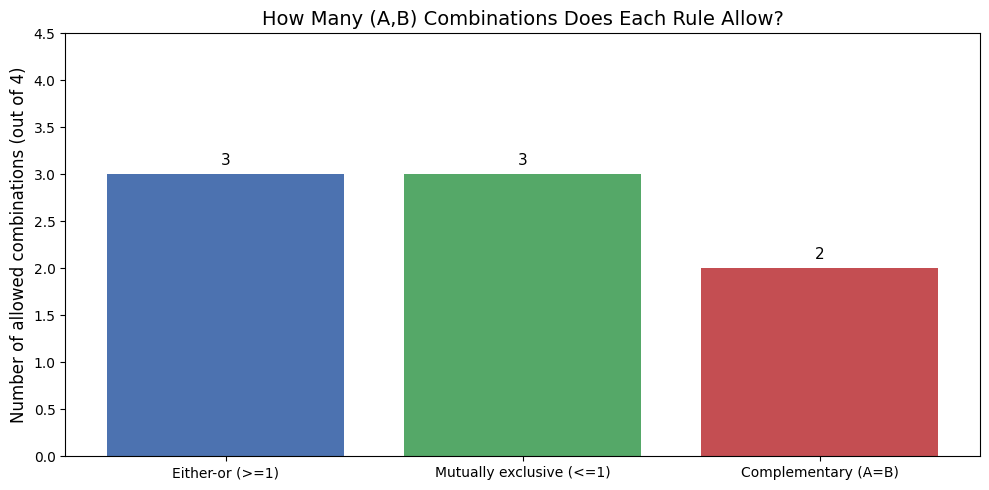

In [7]:
# Bar chart of how many combinations each rule allows

patterns = ["Either-or (>=1)", "Mutually exclusive (<=1)", "Complementary (A=B)"]
allowed_counts = [valid_count, valid_count_mutex, valid_count_comp]

fig, ax = plt.subplots()

bars = ax.bar(patterns, allowed_counts, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("How Many (A,B) Combinations Does Each Rule Allow?")
ax.set_ylabel("Number of allowed combinations (out of 4)")
ax.set_ylim(0, 4.5)

for bar, count in zip(bars, allowed_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, str(int(count)), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## Conclusion: Reading Policy Language Carefully

In this notebook, you saw that:

- **Either-or (≥1)** allows A only, B only, or both – it only forbids "neither".
- **Mutually exclusive (≤1)** allows A only, B only, or neither – it only forbids "both".
- **Complementary (A = B)** allows only "both" or "neither" – it forbids mixed choices.

Small changes in policy wording ("at least one", "at most one", "both or neither") map to **different constraints and different feasible combinations**.
Getting this mapping right is essential for building models that match the true intent of business rules.